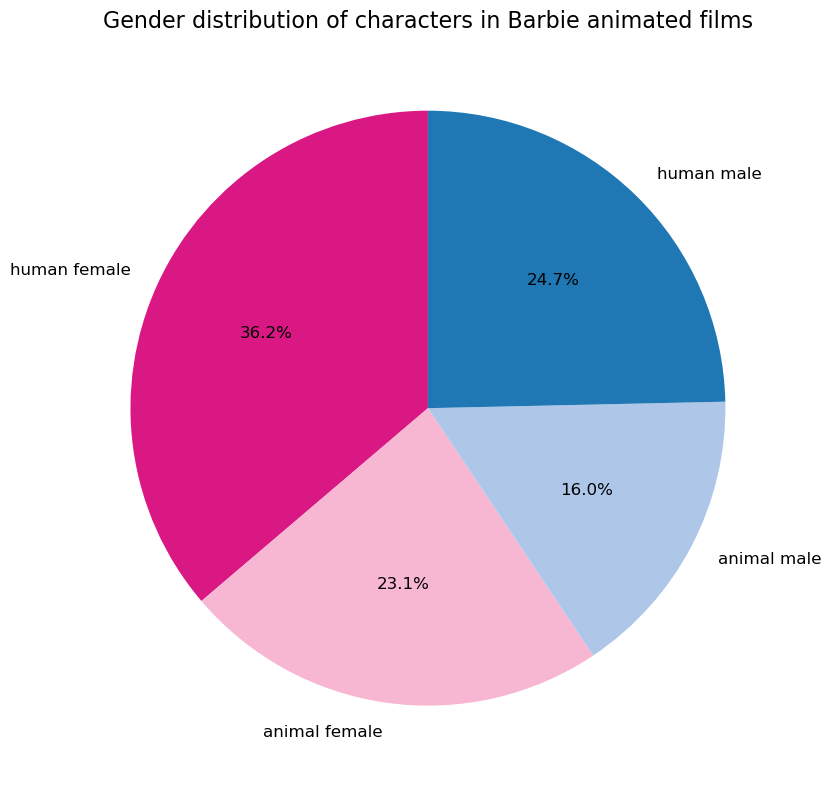

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/majazontek/Desktop/UCZELNIA/2 rok/wizualizacja danych/projekt/do wyslania do 23.12.25/Barbieverse Characters.csv')
df['Gender'] = df['Gender'].str.strip()
df = df.dropna(subset=['Gender'])

def get_category(row):
    race = str(row['Race']).lower()
    gender = str(row['Gender']).lower()
    species = 'human' if 'human' in race else 'animal'
    return f"{species} {gender}"

df['Category'] = df.apply(get_category, axis=1)

target_categories = ['human female', 'human male', 'animal female', 'animal male']
df_filtered = df[df['Category'].isin(target_categories)]
counts = df_filtered['Category'].value_counts()

desired_order = ['human female', 'animal female', 'animal male', 'human male']

counts_ordered = counts.reindex(desired_order).fillna(0)

plt.figure(figsize=(10, 8))

color_map = {
    'human female': '#da1884',
    'animal female': '#f7b6d2',
    'animal male': '#aec7e8',
    'human male': '#1f77b4'
}
colors = [color_map[cat] for cat in counts_ordered.index]

plt.pie(counts_ordered,
        labels=counts_ordered.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=True,
        colors=colors,
        textprops={'fontsize': 12})

plt.title('Gender distribution of characters in Barbie animated films', fontsize=16)
plt.tight_layout()
plt.savefig('genders.png')
plt.show()